In [3]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
import numpy as np
import json
from tensorflow import keras

# Load validation data (and test, for later use in Phase 8)
X_val  = np.load('../data/X_val.npy', allow_pickle=True).astype('float32')
y_val  = np.load('../data/y_val.npy', allow_pickle=True).astype('float32')
X_test = np.load('../data/X_test.npy', allow_pickle=True).astype('float32')
y_test = np.load('../data/y_test.npy', allow_pickle=True).astype('float32')

with open('../data/feature_names.json') as f:
    feature_names = json.load(f)

# Load your trained neural network
model = keras.models.load_model('../models/neural_network.keras')
model.summary()   # sanity check — should show the same architecture as before

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,669 (22.15 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,780 (14.77 KB)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


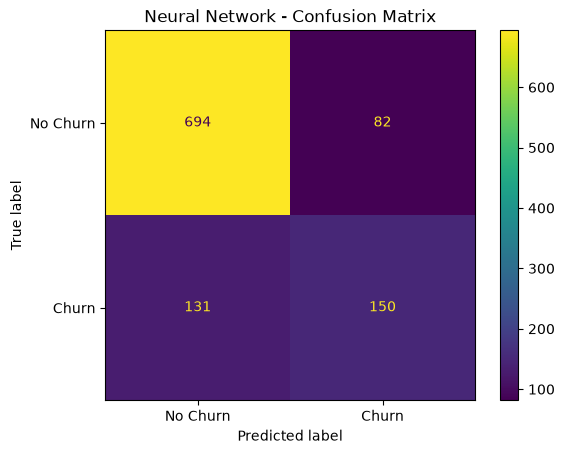

In [6]:
y_pred_proba = model.predict(X_val).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot()
plt.title('Neural Network - Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_val, y_pred))



              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87       776
         1.0       0.65      0.53      0.58       281

    accuracy                           0.80      1057
   macro avg       0.74      0.71      0.73      1057
weighted avg       0.79      0.80      0.79      1057



In [9]:
auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8441


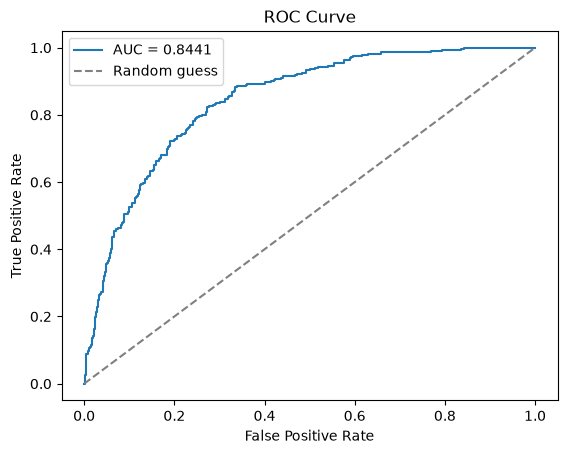

In [10]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.show()

In [11]:
y_pred_lower = (y_pred_proba > 0.35).astype(int)
print(classification_report(y_val, y_pred_lower))

              precision    recall  f1-score   support

         0.0       0.88      0.82      0.85       776
         1.0       0.58      0.69      0.63       281

    accuracy                           0.78      1057
   macro avg       0.73      0.75      0.74      1057
weighted avg       0.80      0.78      0.79      1057



**Logistic Regression vs. Neural Network**

| Metric              | Logistic Regression | Neural Network (0.5) | Neural Network (0.35) |
|---------------------|:--------------------:|:----------------------:|:------------------------:|
| Accuracy            | 0.80                 | 0.80                   | 0.78                     |
| Churn Precision     | 0.64                 | 0.65                   | 0.58                     |
| Churn Recall        | 0.55                 | 0.53                   | **0.69**                 |
| Churn F1            | 0.59                 | 0.58                   | 0.63                     |
| ROC-AUC             | 0.8435               | 0.8441                 | 0.8441 *(same model)*    |

### Interpretation

Logistic Regression and the neural network achieve almost identical ROC-AUC 
(0.8435 vs. 0.8441) — a difference small enough to be noise rather than a 
real gap. This suggests the relationships in this dataset (e.g. tenure, 
contract type, internet service) are largely linear, and the neural 
network's extra hidden layers did not uncover meaningfully new non-linear 
patterns that Logistic Regression's linear decision boundary was missing.

At the default 0.5 threshold, the two models perform almost identically 
across every metric — the neural network does not clearly outperform the 
simpler baseline here.

Where the neural network adds real value is **threshold flexibility**: by 
lowering the decision threshold from 0.5 to 0.35 (using the model's 
probability outputs, guided by its strong ROC-AUC), churn recall improved 
from 0.53 to **0.69** — a meaningful gain for the business case established 
in Phase 1, where missing an actual churner is costlier than a false alarm. 
This came at a modest cost: precision dropped from 0.65 to 0.58, and 
accuracy from 0.80 to 0.78.

**Conclusion:** for this dataset and problem size, a small neural network 
does not clearly outperform a well-tuned Logistic Regression baseline in 
raw discriminative power. Its practical advantage came from threshold 
tuning enabled by inspecting its calibrated probability outputs — 
demonstrating that model choice and decision-threshold choice are two 
separate levers, and business context (not just accuracy) should drive 
the final threshold decision.